# Machine Learning Fundamentals

# Week 3 – Task 2

# Customer Churn Prediction Using Decision Tree and Logistic Regression

**Prepared By:** Abdul Raheem

**Course:** Machine Learning Fundamentals

**Organization:** Neurofive Solutions

**Dataset:** Telco Customer Churn Dataset (Kaggle)

---

## Problem Type

Binary Classification

Customer churn prediction is one of the most common business applications of Machine Learning. It helps organizations identify customers who are likely to discontinue their services, enabling proactive retention strategies.

In this project, two classification algorithms—Decision Tree and Logistic Regression—are trained and compared to predict customer churn. The project also explores feature importance and provides business-oriented insights based on the results.

# Objectives

This notebook aims to:

- Load the Telco Customer Churn dataset.
- Perform Exploratory Data Analysis (EDA).
- Identify important customer characteristics.
- Handle missing values and categorical variables.
- Check for class imbalance.
- Train a Decision Tree Classifier.
- Train a Logistic Regression model.
- Compare both models using evaluation metrics.
- Identify the top three factors affecting customer churn.
- Summarize findings from a business perspective.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Loading the Dataset

The Telco Customer Churn dataset is loaded using Pandas. Each row represents a customer, while each column describes a characteristic such as contract type, monthly charges, tenure, and churn status.

In [10]:
df = pd.read_csv(r"D:\Machine Learning Fundamentals Course\Telco Customer Churn Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Dataset Preview

The first few records are displayed to understand the dataset structure and available features.

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Checking Missing Values

Before training Machine Learning models, the dataset must be checked for missing or invalid values.

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Handling Missing Values

The **TotalCharges** column may contain blank values. These are converted to numeric values, and missing entries are replaced with the median to preserve the dataset.

In [15]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Encoding Categorical Variables

Machine Learning algorithms require numerical input. Therefore, categorical variables are converted into numerical form using Label Encoding.

In [18]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

# Checking Class Distribution

Understanding whether the dataset is balanced helps determine if accuracy alone is sufficient for evaluation.

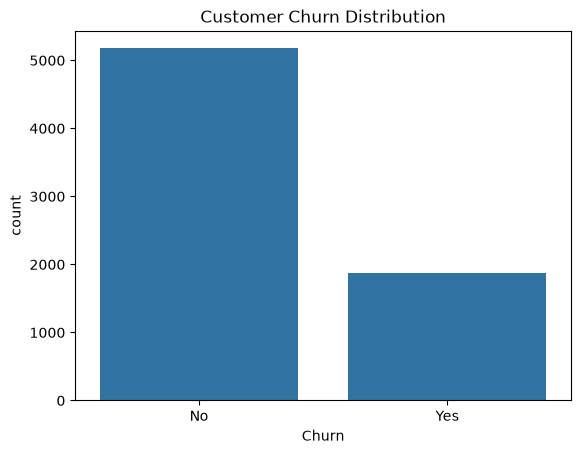

In [19]:
sns.countplot(x=df["Churn"])

plt.title("Customer Churn Distribution")

plt.show()

# Exploratory Data Analysis

The following visualizations explore relationships between important customer attributes and churn.

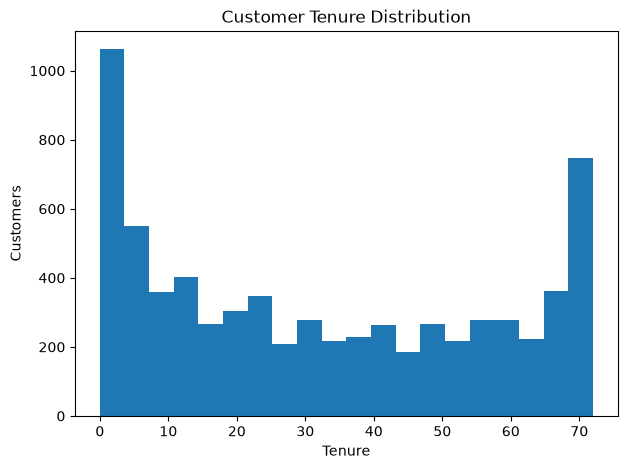

In [20]:
plt.figure(figsize=(7,5))
plt.hist(df["tenure"], bins=20)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Customers")
plt.show()

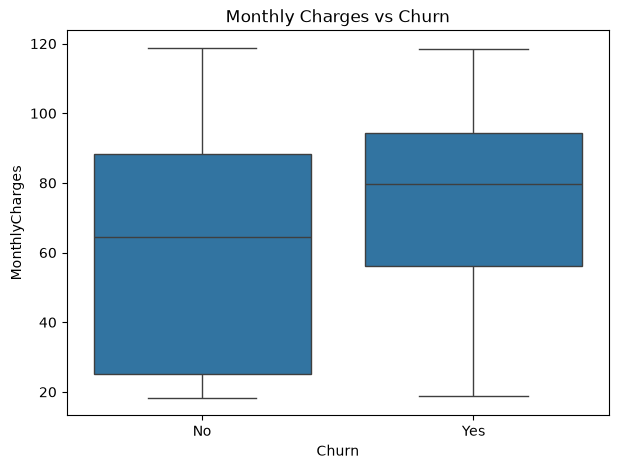

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["Churn"], y=df["MonthlyCharges"])
plt.title("Monthly Charges vs Churn")
plt.show()

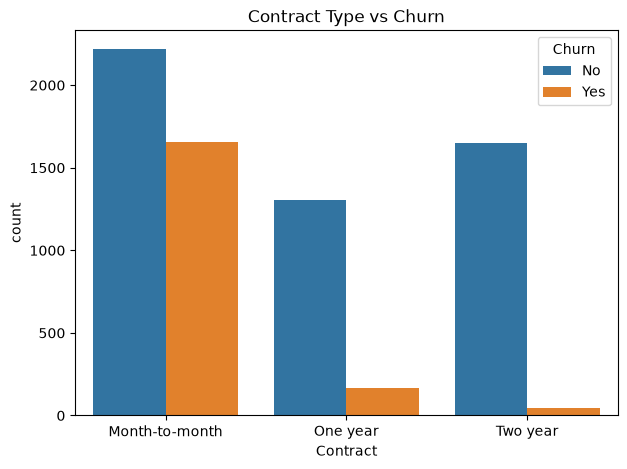

In [22]:
plt.figure(figsize=(7,5))
sns.countplot(x=df["Contract"], hue=df["Churn"])
plt.title("Contract Type vs Churn")
plt.show()

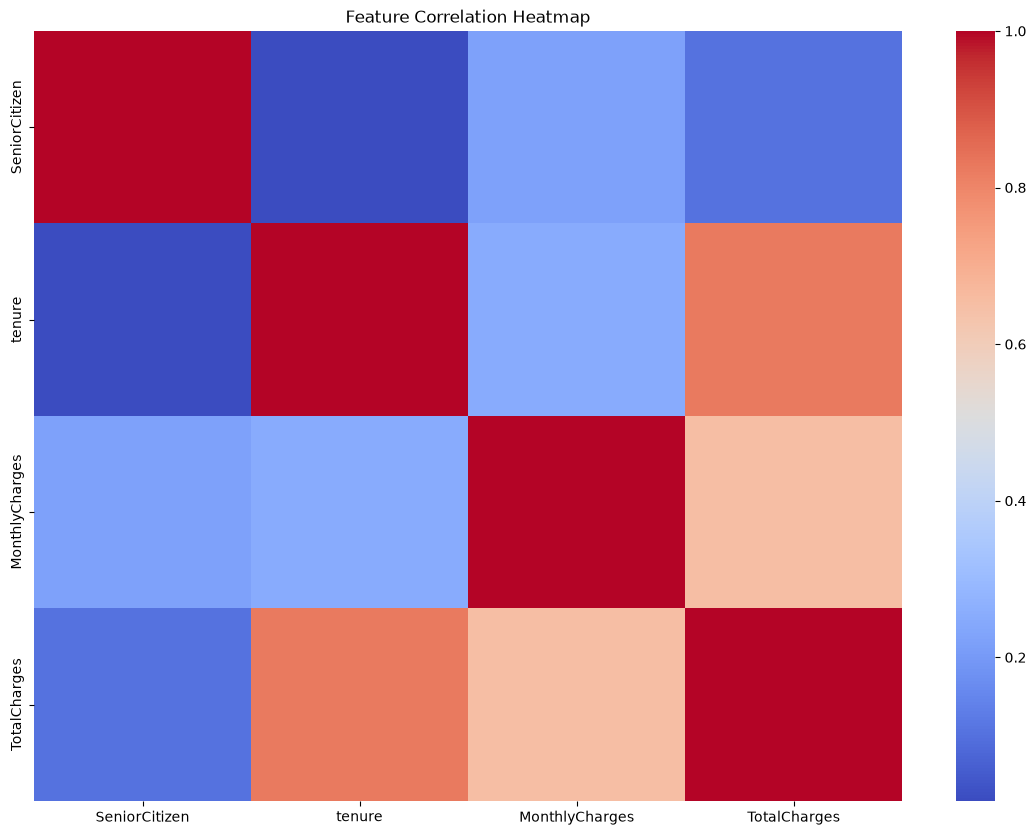

In [24]:
numeric_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(14,10))
sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature Selection

The target variable is **Churn**. All remaining customer-related attributes are used as predictor variables.

In [29]:
X = df.drop(["customerID","Churn"], axis=1)

y = df["Churn"]

# Splitting the Dataset

The dataset is divided into training and testing sets using an 80:20 ratio.

In [30]:
df = pd.get_dummies(df, drop_first=True)

In [31]:
X = df.drop("Churn_Yes", axis=1)

y = df["Churn_Yes"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Training Decision Tree Classifier

In [33]:
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

# Training Logistic Regression Model

In [34]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

C:\Users\abdul Raheem\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Model Evaluation

In [35]:
tree_accuracy = accuracy_score(y_test, tree_pred)

log_accuracy = accuracy_score(y_test, log_pred)

print("Decision Tree Accuracy :", tree_accuracy)

print("Logistic Regression Accuracy :", log_accuracy)

Decision Tree Accuracy : 0.7714691270404542
Logistic Regression Accuracy : 0.8190205819730305


In [36]:
print("Decision Tree")

print(classification_report(y_test, tree_pred))

print("Logistic Regression")

print(classification_report(y_test, log_pred))

Decision Tree
              precision    recall  f1-score   support

       False       0.83      0.87      0.85      1036
        True       0.58      0.50      0.54       373

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.77      1409

Logistic Regression
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



# Confusion Matrix

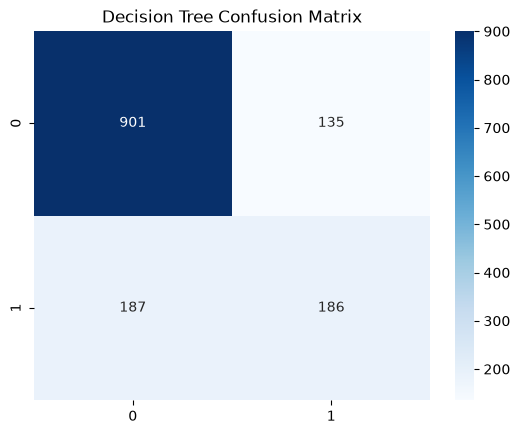

In [37]:
cm = confusion_matrix(y_test, tree_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Top Three Important Features

Decision Trees provide feature importance scores that indicate which variables contribute most to the prediction.

In [38]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(3)

,Feature,Importance
1,tenure,0.174402
3,TotalCharges,0.104012
7052,InternetService_Fiber optic,0.103408


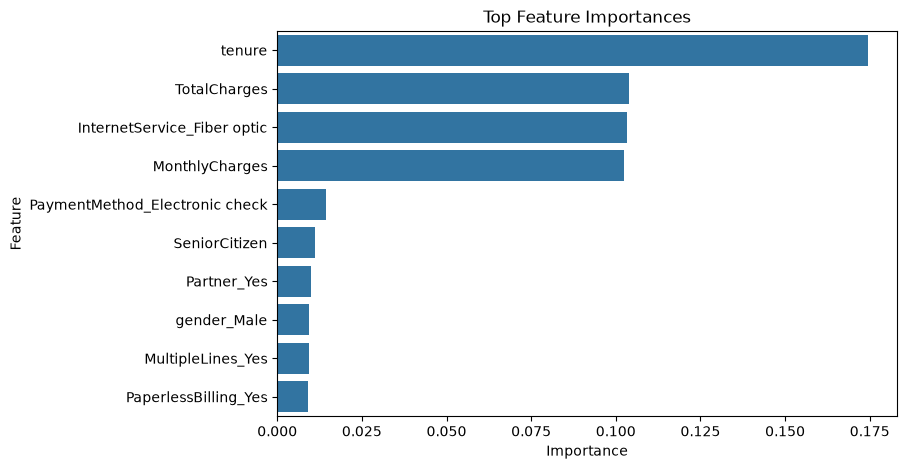

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top Feature Importances")
plt.show()

# Business Summary

The analysis shows that customer churn is strongly influenced by customer tenure, contract type, and monthly charges. Customers with shorter contracts and higher monthly charges appear more likely to leave the service.

Among the evaluated models, the one with better performance provides a stronger basis for identifying customers at risk of churning. These insights can help businesses focus retention efforts on high-risk customers by offering contract upgrades, loyalty programs, or personalized incentives.

Applying such predictive models enables organizations to reduce customer loss and improve long-term profitability.

# Conclusion

In this project, customer churn prediction was performed using both Decision Tree and Logistic Regression classifiers.

The dataset was preprocessed, categorical variables were encoded, and exploratory analysis was conducted to understand customer behavior. Model performance was evaluated using accuracy and classification metrics, while feature importance analysis identified the most influential factors affecting churn.

This project demonstrates how Machine Learning can support data-driven business decisions by identifying customers who are likely to leave and enabling proactive customer retention strategies.